In [1]:
import sys
assert sys.version_info>=(3,5)

IS_COLAB="google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

import sklearn 
assert sklearn.__version__ >= "0.20"

import numpy as np
import os 
np.random.seed(42)

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt 
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

PROJECT_ROOT_DIR="."
CHAPTER_ID="classification"
IMAGES_PATH=os.path.join(PROJECT_ROOT_DIR,"images",CHAPTER_ID)
os.makedirs(IMAGES_PATH,exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [2]:
import pandas as pd 
data=pd.read_csv(r"E:\digit-recognizer\train.csv")
print(data.shape)

(42000, 785)


In [45]:
X=data.drop("label",axis=1).values
y=data["label"].values
X.shape

(42000, 784)

In [47]:
X=X.reshape(-1,28,28)
X.shape

(42000, 28, 28)

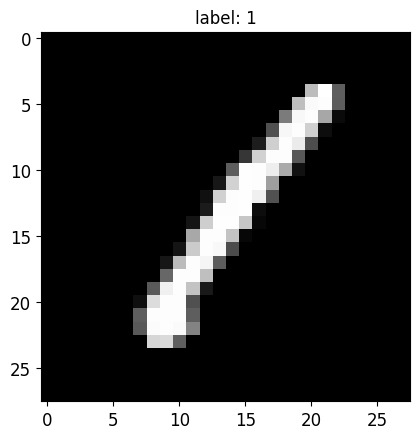

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X[0],cmap="gray")
plt.title(f"label: {y[0]}")
plt.show()

In [6]:
y[0]

np.int64(1)

In [7]:
#Binary Classifier
y_train_5=(y == 5)
X = X.reshape(-1, 28*28)

In [8]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(max_iter=1000,tol=1e-3,random_state=42)
sgd_clf.fit(X,y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [9]:
some_digit=X[0]
sgd_clf.predict([some_digit])

array([False])

In [10]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X,y_train_5,cv=3,scoring="accuracy")

array([0.9635    , 0.9665    , 0.95835714])

In [11]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self,X,y=None):
        pass
    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)


In [12]:
never_5=Never5Classifier()
cross_val_score(never_5,X,y_train_5,cv=3,scoring="accuracy")

array([0.90885714, 0.91107143, 0.909     ])

In [13]:
from sklearn.model_selection import cross_val_predict
y_pred=cross_val_predict(sgd_clf,X,y_train_5,cv=3)

In [14]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_pred)

array([[37781,   424],
       [ 1139,  2656]])

In [15]:
from sklearn.metrics import precision_score,recall_score
precision_score(y_train_5,y_pred)


0.8623376623376623

In [16]:
recall_score(y_train_5,y_pred)

0.6998682476943346

In [17]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_pred)

0.7726545454545455

In [18]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([-16346.9223577])

In [19]:
from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(sgd_clf, X, y_train_5, cv=3,
                             method="decision_function")
precision,recall,threshold=precision_recall_curve(y_train_5,y_scores)
threshold_90=threshold[np.argmax(precision>=0.90)]

In [20]:
threshold_90


np.float64(1212.8754158884142)

In [21]:
y_train_pred_90=(y_scores >= threshold_90 )
precision_score(y_train_5,y_train_pred_90)


0.9002900652646846

In [22]:
recall_score(y_train_5,y_train_pred_90)


0.6542819499341238

In [23]:
from sklearn.metrics import roc_curve


fpr,tpr,threshold=roc_curve(y_train_5,y_scores)
recall_90_precision=recall_score(y_train_5,y_train_pred_90)

Saving figure roc_curve_plot


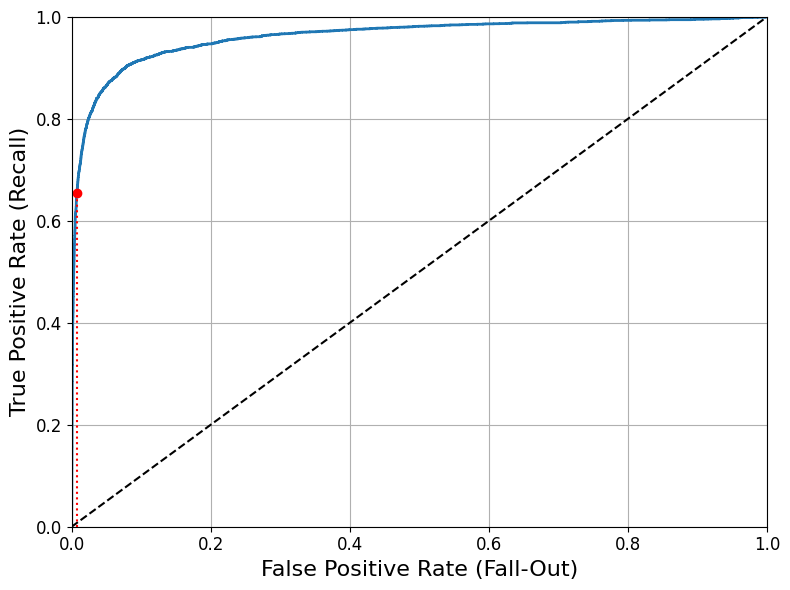

In [24]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])                                    # Not shown in the book
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) # Not shown
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)    # Not shown
    plt.grid(True)                                            # Not shown

plt.figure(figsize=(8, 6))                                    # Not shown
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]           # Not shown
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")   # Not shown
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")  # Not shown
plt.plot([fpr_90], [recall_90_precision], "ro")               # Not shown
save_fig("roc_curve_plot")                                    # Not shown
plt.show()

In [25]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9621962511028932

In [26]:
from sklearn.ensemble import RandomForestClassifier
forest_clf=RandomForestClassifier(random_state=42)
y_probas_forest=cross_val_predict(forest_clf,X,y_train_5,cv=3,method="predict_proba")

In [27]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

In [28]:
recall_forest=tpr_forest[np.argmax(fpr_forest>=fpr_90)]

Saving figure roc_curve_comparison_plot


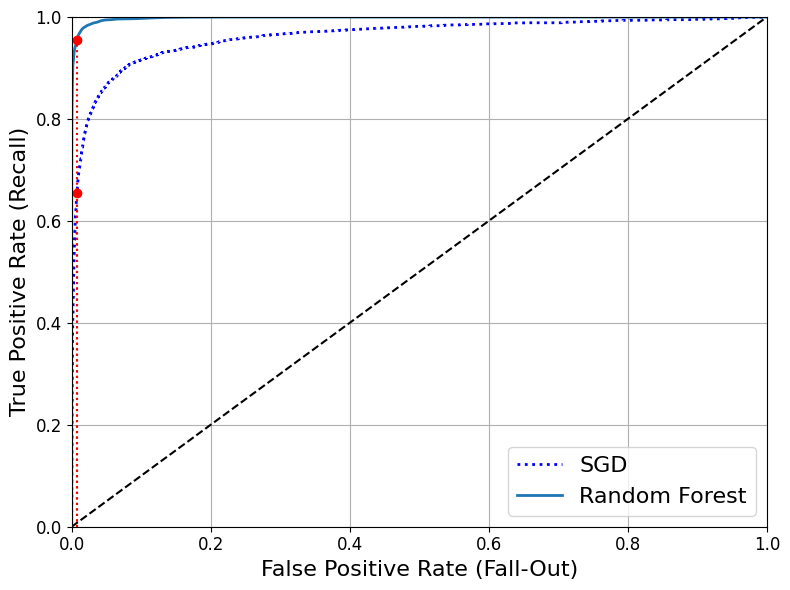

In [29]:

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
plt.plot([fpr_90, fpr_90], [0., recall_forest], "r:")
plt.plot([fpr_90], [recall_forest], "ro")
plt.grid(True)
plt.legend(loc="lower right", fontsize=16)
save_fig("roc_curve_comparison_plot")
plt.show()

In [30]:
roc_auc_score(y_train_5,y_scores_forest)

0.9983586742279834

In [31]:
y_train_pred_forest=cross_val_predict(forest_clf,X,y_train_5,cv=3)
precision_score(y_train_5,y_train_pred_forest)

0.9907235621521335

In [32]:
recall_score(y_train_5,y_train_pred_forest)

0.8442687747035573

In [33]:
cross_val_score(forest_clf,X,y_train_5,cv=3,scoring="accuracy")

array([0.98442857, 0.986     , 0.98521429])

In [35]:
#Multiclass Classifier using OVR
X_OVR=X
y_OVR=y
classes=np.unique(y_OVR)
ovr_model={}

for cls in classes:
    print(f"Training classifier for class {cls}")

    #create binary target 
    y_binary = (y_OVR== cls)

    clf = RandomForestClassifier(random_state=42)
    clf.fit(X,y_binary)

    ovr_model[cls]=clf

Training classifier for class 0
Training classifier for class 1
Training classifier for class 2
Training classifier for class 3
Training classifier for class 4
Training classifier for class 5
Training classifier for class 6
Training classifier for class 7
Training classifier for class 8
Training classifier for class 9


In [36]:
def ovr_predict(X_OVR):
    probs=[]

    for cls in classes:
        clf=ovr_model[cls]
        prob=clf.predict_proba(X_OVR)[:,1]
        probs.append(prob)

    probs=np.array(probs).T
    return np.argmax(probs,axis=1)

In [52]:


test=pd.read_csv(r"E:\digit-recognizer\test.csv")
test=test.values.reshape(-1,28,28)
test=test.reshape(-1,28*28)
y_pred= ovr_predict(test)




In [53]:
import pandas as pd

submission = pd.DataFrame({
    "ImageId": range(1, len(y_pred) + 1),
    "Label": y_pred
})

submission.to_csv("submission.csv", index=False)

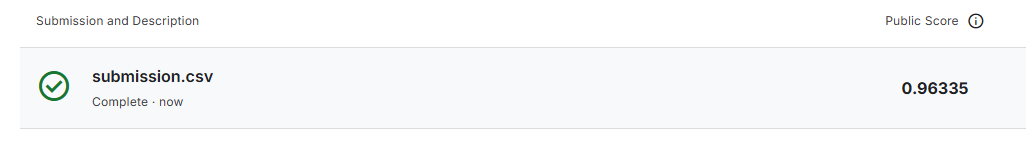